# Tarea Clase 1 — Deep Learning (UAI)

**Autor:** _[Completar nombre]_  
**Curso:** Deep Learning  
**Fecha:** _[Completar fecha]_

## 1) Introducción

En esta tarea construyo y analizo un **Multilayer Perceptron (MLP)** para clasificación de imágenes manuscritas. El objetivo es conectar la teoría de la Clase 1 (perceptrón, limitación con XOR, capas ocultas, activaciones y backpropagation) con una implementación real en un problema supervisado de clasificación multiclase.

Trabajaré con **MNIST** y compararé dos versiones del modelo: una base y otra mejorada con regularización y *Early Stopping*.

## 2) Marco teórico

### ¿Qué es un perceptrón?
Un perceptrón es el bloque más simple de una red neuronal: recibe entradas, calcula una combinación lineal y aplica una función de activación para producir una salida.

### ¿Qué problema resuelve?
Puede resolver problemas **linealmente separables**, por ejemplo cuando una sola recta (o hiperplano) separa las clases.

### ¿Por qué no puede resolver XOR?
XOR no es linealmente separable: no existe una sola frontera lineal que separe correctamente sus clases. Por eso un perceptrón de una sola capa falla en XOR.

### ¿Qué es un MLP?
Un **MLP** agrega una o más capas ocultas entre entrada y salida. Esto permite aprender transformaciones no lineales y representar fronteras de decisión más complejas.

### Rol de las capas ocultas
Las capas ocultas aprenden representaciones intermedias útiles del dato. En imágenes, pueden combinar patrones básicos para formar características más informativas para clasificar.

### Funciones de activación (ReLU y Sigmoid)
- **ReLU**: introduce no linealidad de forma eficiente y suele entrenar más rápido.
- **Sigmoid**: acota salidas entre 0 y 1, útil en ciertos contextos, pero puede saturarse en redes profundas.

### ¿Qué es backpropagation (conceptual)?
Backpropagation es el mecanismo para ajustar pesos: calcula cuánto aportó cada parámetro al error final y actualiza los pesos en dirección de menor pérdida (normalmente usando descenso de gradiente y variantes como Adam).

### Conexión teoría–implementación
En esta tarea, el paso de un perceptrón simple a un MLP con activaciones no lineales explica por qué el modelo puede resolver tareas complejas como clasificación de dígitos, donde una frontera lineal única es insuficiente.

In [43]:
# Instalación automática de dependencias (solo si faltan)
import importlib
import subprocess
import sys

required = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'tensorflow': 'tensorflow'
}

missing = []
for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(package_name)

if missing:
    print('Instalando paquetes faltantes:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('Todas las dependencias ya están instaladas.')

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import Markdown, display

print('TensorFlow:', tf.__version__)

Todas las dependencias ya están instaladas.
TensorFlow: 2.19.0


In [44]:
# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# (Opcional) para mayor determinismo en CPU/GPU
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

## 3) Carga y Exploración de Datos (EDA)

In [45]:
# Carga de MNIST
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Trabajar sobre copia de datos (buena práctica)
X_train_full = X_train_full.copy()
y_train_full = y_train_full.copy()
X_test = X_test.copy()
y_test = y_test.copy()

print('X_train_full:', X_train_full.shape)
print('y_train_full:', y_train_full.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train_full: (60000, 28, 28)
y_train_full: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


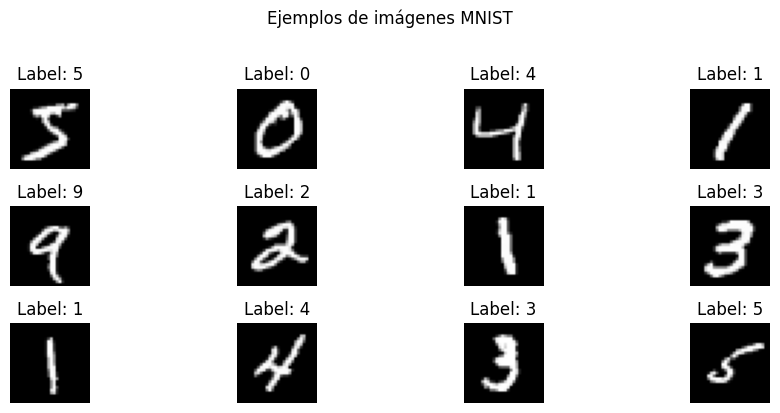

In [46]:
# Visualizar ejemplos
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(f'Label: {y_train_full[i]}')
    plt.axis('off')
plt.suptitle('Ejemplos de imágenes MNIST', y=1.02)
plt.tight_layout()
plt.show()

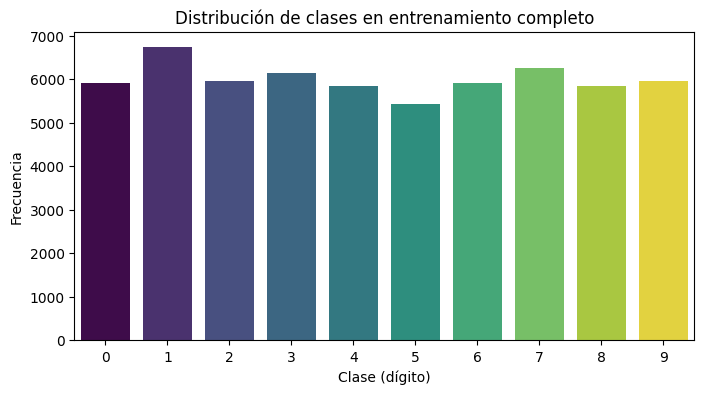

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [47]:
# Distribución de clases
classes, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=classes, y=counts, palette='viridis', hue=classes, legend=False)
plt.title('Distribución de clases en entrenamiento completo')
plt.xlabel('Clase (dígito)')
plt.ylabel('Frecuencia')
plt.show()

print(dict(zip(classes, counts)))

In [48]:
# Análisis EDA (obligatorio)
class_freq = counts / counts.sum()
imbalance = class_freq.max() - class_freq.min()
majority = classes[np.argmax(counts)]
minority = classes[np.argmin(counts)]

eda_text = f"""
### 📊 Análisis EDA
- **¿Qué estoy viendo?** La distribución de clases en MNIST es casi uniforme: la clase más frecuente es **{majority}** y la menos frecuente es **{minority}**.
- **¿Por qué ocurre?** MNIST fue curado para tener representación similar de cada dígito, por eso el desbalance global es bajo.
- **¿Es bueno o malo?** Es **bueno**: el gap relativo entre clase mayoritaria y minoritaria es de **{imbalance*100:.2f}%**, señal de bajo riesgo de sesgo por frecuencia.
- **¿Qué implica para el modelo?** Esperamos que la accuracy global sea representativa; si falla en una clase específica, probablemente será por dificultad visual y no por falta de datos.
"""
display(Markdown(eda_text))



### 📊 Análisis EDA
- **¿Qué estoy viendo?** La distribución de clases en MNIST es casi uniforme: la clase más frecuente es **1** y la menos frecuente es **5**.
- **¿Por qué ocurre?** MNIST fue curado para tener representación similar de cada dígito, por eso el desbalance global es bajo.
- **¿Es bueno o malo?** Es **bueno**: el gap relativo entre clase mayoritaria y minoritaria es de **2.20%**, señal de bajo riesgo de sesgo por frecuencia.
- **¿Qué implica para el modelo?** Esperamos que la accuracy global sea representativa; si falla en una clase específica, probablemente será por dificultad visual y no por falta de datos.


## 4) Preprocesamiento

- **Normalización:** escalamos pixeles de [0, 255] a [0, 1] para estabilizar entrenamiento.
- **Flatten:** MLP espera vectores, por eso convertimos cada imagen 28x28 en vector de 784.
- **Split train/validation/test:** separamos validación para monitorear generalización durante entrenamiento.
- **Etiquetas:** usamos enteros de clase y `sparse_categorical_crossentropy` (no requiere one-hot).

In [49]:
# Normalización
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten: (n, 28, 28) -> (n, 784)
X_train_full_flat = X_train_full.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_flat,
    y_train_full,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train_full,
)

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test_flat.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


## 5) Construcción del Modelo (MLP base)

Arquitectura base:
- Capa de entrada de tamaño 784 (imagen aplanada).
- Dos capas ocultas densas con ReLU para modelar no linealidades.
- Capa de salida de 10 neuronas (una por dígito) con `softmax` para probabilidades por clase.

In [50]:
def build_base_mlp(input_dim=784, num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

base_model = build_base_mlp()
base_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6) Compilación y Entrenamiento

In [51]:
base_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_base = base_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=128,
    verbose=1
)

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9031 - loss: 0.3451 - val_accuracy: 0.9465 - val_loss: 0.1909
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9565 - loss: 0.1463 - val_accuracy: 0.9585 - val_loss: 0.1468
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9687 - loss: 0.1041 - val_accuracy: 0.9650 - val_loss: 0.1260
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9765 - loss: 0.0791 - val_accuracy: 0.9692 - val_loss: 0.1138
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9819 - loss: 0.0623 - val_accuracy: 0.9717 - val_loss: 0.1055
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9858 - loss: 0.0496 - val_accuracy: 0.9733 - val_loss: 0.1018
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9887 - loss: 0.0401 - val_accuracy: 0.9740 - val_loss: 0.0984
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9910 - loss: 0.0321 - val_accuracy: 

In [52]:
# Análisis posterior al entrenamiento base (obligatorio)
hb = history_base.history
n_ep = len(hb['loss'])
loss_drop = hb['loss'][0] - hb['loss'][-1]
acc_gain = hb['accuracy'][-1] - hb['accuracy'][0]
val_gap = hb['accuracy'][-1] - hb['val_accuracy'][-1]

if val_gap > 0.03:
    fit_state = 'posible overfitting'
elif hb['val_accuracy'][-1] < 0.90 and hb['accuracy'][-1] < 0.90:
    fit_state = 'posible underfitting'
else:
    fit_state = 'ajuste razonable'

train_text = f"""
### 🏋️ Análisis de entrenamiento (modelo base)
- **¿Qué estoy viendo?** En {n_ep} épocas, la loss de entrenamiento cae **{loss_drop:.4f}** y la accuracy sube **{acc_gain:.4f}**.
- **¿Por qué ocurre?** El optimizador Adam ajusta los pesos para reducir error de clasificación sobre minibatches.
- **¿Es bueno o malo?** Es **bueno** que loss baje y accuracy suba; aun así, la brecha train-val final es **{val_gap:.4f}**.
- **¿Qué implica para el modelo?** El patrón sugiere **{fit_state}**; conviene validar con las curvas y revisar regularización si la brecha crece.
"""
display(Markdown(train_text))



### 🏋️ Análisis de entrenamiento (modelo base)
- **¿Qué estoy viendo?** En 12 épocas, la loss de entrenamiento cae **0.3287** y la accuracy sube **0.0927**.
- **¿Por qué ocurre?** El optimizador Adam ajusta los pesos para reducir error de clasificación sobre minibatches.
- **¿Es bueno o malo?** Es **bueno** que loss baje y accuracy suba; aun así, la brecha train-val final es **0.0219**.
- **¿Qué implica para el modelo?** El patrón sugiere **ajuste razonable**; conviene validar con las curvas y revisar regularización si la brecha crece.


## 7) Análisis de Entrenamiento

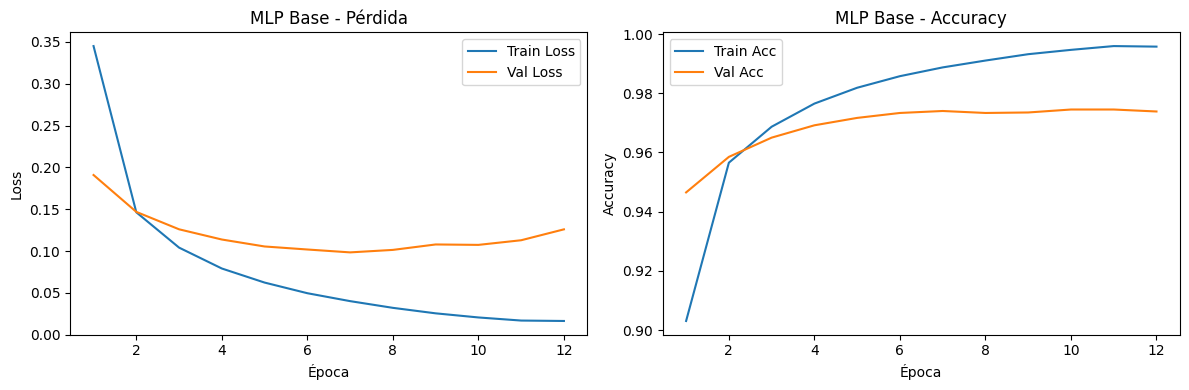

In [53]:
def plot_history(history, title_prefix='Modelo'):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['loss'], label='Train Loss')
    plt.plot(epochs, hist['val_loss'], label='Val Loss')
    plt.title(f'{title_prefix} - Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['accuracy'], label='Train Acc')
    plt.plot(epochs, hist['val_accuracy'], label='Val Acc')
    plt.title(f'{title_prefix} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_base, title_prefix='MLP Base')

In [54]:
# Diagnóstico explícito de curvas (obligatorio)
train_acc_f = history_base.history['accuracy'][-1]
val_acc_f = history_base.history['val_accuracy'][-1]
train_loss_f = history_base.history['loss'][-1]
val_loss_f = history_base.history['val_loss'][-1]
acc_gap = train_acc_f - val_acc_f
loss_gap = val_loss_f - train_loss_f

if abs(acc_gap) <= 0.02 and abs(loss_gap) <= 0.05:
    diag = 'train ≈ validation → buen ajuste'
elif acc_gap > 0.03 and loss_gap > 0.05:
    diag = 'train >> validation → overfitting'
else:
    diag = 'ambos malos o brecha intermedia → underfitting parcial o ajuste inestable'

display(Markdown(f"""
### 📉 Lectura de gráficos de loss/accuracy
- **¿Qué estoy viendo?** Accuracy final train/val: **{train_acc_f:.4f}/{val_acc_f:.4f}**; loss final train/val: **{train_loss_f:.4f}/{val_loss_f:.4f}**.
- **Diagnóstico explícito:** **{diag}**.
- **¿Es bueno o malo?** Si la brecha se mantiene pequeña, el modelo generaliza bien; brechas altas indican memorización.
- **¿Qué implica para el modelo?** Este diagnóstico define si conviene aumentar capacidad, regularizar o detener antes.
"""))



### 📉 Lectura de gráficos de loss/accuracy
- **¿Qué estoy viendo?** Accuracy final train/val: **0.9957/0.9738**; loss final train/val: **0.0164/0.1259**.
- **Diagnóstico explícito:** **ambos malos o brecha intermedia → underfitting parcial o ajuste inestable**.
- **¿Es bueno o malo?** Si la brecha se mantiene pequeña, el modelo generaliza bien; brechas altas indican memorización.
- **¿Qué implica para el modelo?** Este diagnóstico define si conviene aumentar capacidad, regularizar o detener antes.


**Interpretación inicial:**

Si la curva de entrenamiento mejora pero validación se estanca o empeora, hay señales de **overfitting**. Si ambas curvas quedan bajas, puede haber **underfitting**. Estas observaciones guían la mejora de arquitectura y regularización.

## 8) Evaluación del Modelo (test set)

In [55]:
test_loss_base, test_acc_base = base_model.evaluate(X_test_flat, y_test, verbose=0)
print(f'Base - Test Loss: {test_loss_base:.4f}')
print(f'Base - Test Accuracy: {test_acc_base:.4f}')

Base - Test Loss: 0.1040
Base - Test Accuracy: 0.9733


In [56]:
# Análisis de evaluación final base (obligatorio)
base_eval = f"""
### ✅ Evaluación final (modelo base)
- **¿Qué estoy viendo?** En test, el modelo base logra **accuracy={test_acc_base:.4f}** y **loss={test_loss_base:.4f}**.
- **¿Por qué ocurre?** El desempeño refleja qué tan bien generaliza lo aprendido en entrenamiento/validación hacia datos no vistos.
- **¿Es bueno o malo?** Para MNIST, una accuracy en torno a 97%-98% es sólida para un MLP simple; valores más altos suelen requerir arquitectura más robusta.
- **¿Qué implica para el modelo?** Sirve como línea base confiable para medir mejoras reales en la siguiente sección.
"""
display(Markdown(base_eval))



### ✅ Evaluación final (modelo base)
- **¿Qué estoy viendo?** En test, el modelo base logra **accuracy=0.9733** y **loss=0.1040**.
- **¿Por qué ocurre?** El desempeño refleja qué tan bien generaliza lo aprendido en entrenamiento/validación hacia datos no vistos.
- **¿Es bueno o malo?** Para MNIST, una accuracy en torno a 97%-98% es sólida para un MLP simple; valores más altos suelen requerir arquitectura más robusta.
- **¿Qué implica para el modelo?** Sirve como línea base confiable para medir mejoras reales en la siguiente sección.


## 9) Análisis Profundo

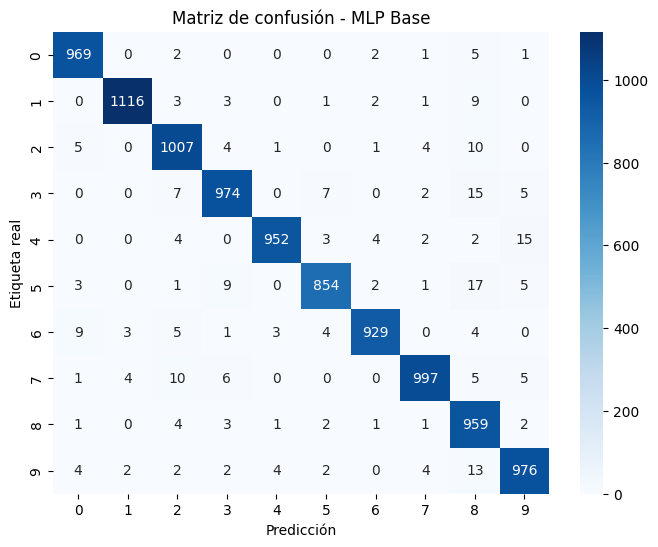

Reporte de clasificación (base):
              precision    recall  f1-score   support

           0     0.9768    0.9888    0.9828       980
           1     0.9920    0.9833    0.9876      1135
           2     0.9636    0.9758    0.9697      1032
           3     0.9721    0.9644    0.9682      1010
           4     0.9906    0.9695    0.9799       982
           5     0.9782    0.9574    0.9677       892
           6     0.9872    0.9697    0.9784       958
           7     0.9842    0.9698    0.9770      1028
           8     0.9230    0.9846    0.9528       974
           9     0.9673    0.9673    0.9673      1009

    accuracy                         0.9733     10000
   macro avg     0.9735    0.9730    0.9731     10000
weighted avg     0.9737    0.9733    0.9734     10000



In [57]:
# Predicciones del modelo base
y_proba_base = base_model.predict(X_test_flat, verbose=0)
y_pred_base = np.argmax(y_proba_base, axis=1)

# Matriz de confusión
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - MLP Base')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.show()

print('Reporte de clasificación (base):')
print(classification_report(y_test, y_pred_base, digits=4))

In [58]:
# Análisis de matriz de confusión (obligatorio)
cm_no_diag = cm_base.copy()
np.fill_diagonal(cm_no_diag, 0)
real_cls, pred_cls = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
max_conf = cm_no_diag[real_cls, pred_cls]

display(Markdown(f"""
### 🔎 Análisis matriz de confusión (modelo base)
- **¿Qué estoy viendo?** La mayor confusión está en **real={real_cls} → pred={pred_cls}** con **{max_conf}** casos.
- **¿Por qué ocurre?** Estas clases suelen compartir trazos (curvatura/inclinación), y el MLP plano no explota estructura espacial completa.
- **¿Es bueno o malo?** Es esperable en dígitos visualmente parecidos; no es crítico si el volumen es bajo respecto al total de la clase.
- **¿Qué implica para el modelo?** Las próximas mejoras deberían apuntar a reducir estas confusiones específicas, no solo subir la accuracy global.
"""))



### 🔎 Análisis matriz de confusión (modelo base)
- **¿Qué estoy viendo?** La mayor confusión está en **real=5 → pred=8** con **17** casos.
- **¿Por qué ocurre?** Estas clases suelen compartir trazos (curvatura/inclinación), y el MLP plano no explota estructura espacial completa.
- **¿Es bueno o malo?** Es esperable en dígitos visualmente parecidos; no es crítico si el volumen es bajo respecto al total de la clase.
- **¿Qué implica para el modelo?** Las próximas mejoras deberían apuntar a reducir estas confusiones específicas, no solo subir la accuracy global.


Total mal clasificados (base): 267


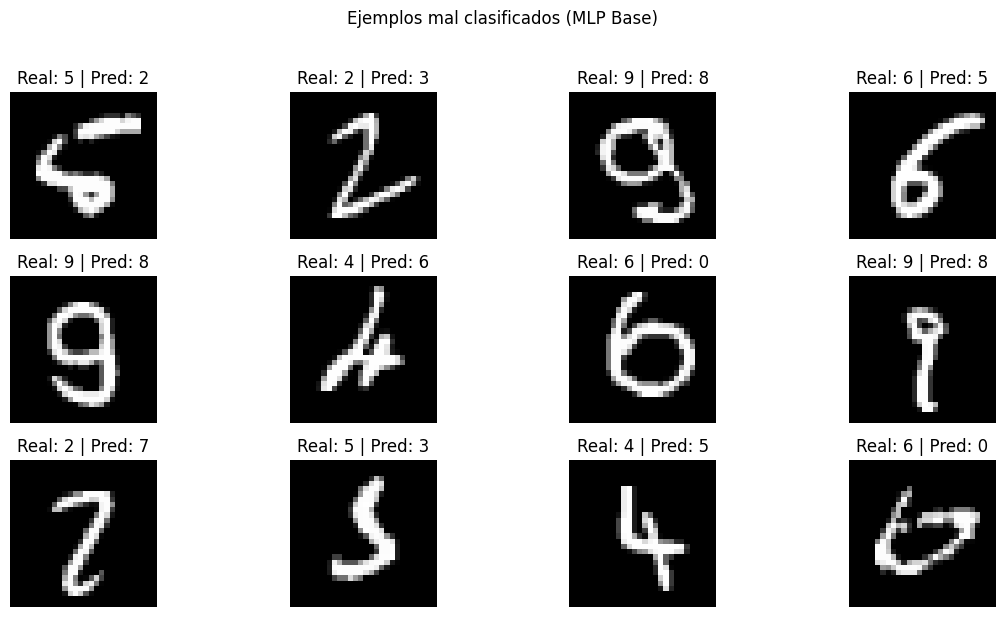

In [59]:
# Ejemplos mal clasificados
mis_idx = np.where(y_pred_base != y_test)[0]
print(f'Total mal clasificados (base): {len(mis_idx)}')

n_show = 12
show_idx = mis_idx[:n_show]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(show_idx):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'Real: {y_test[idx]} | Pred: {y_pred_base[idx]}')
    plt.axis('off')
plt.suptitle('Ejemplos mal clasificados (MLP Base)', y=1.02)
plt.tight_layout()
plt.show()

In [60]:
# Análisis crítico por error individual (obligatorio)
print('Análisis de cada imagen mal clasificada mostrada:')
for i, idx in enumerate(show_idx, start=1):
    true_c = y_test[idx]
    pred_c = y_pred_base[idx]
    top2 = np.argsort(y_proba_base[idx])[-2:][::-1]
    p1, p2 = y_proba_base[idx][top2[0]], y_proba_base[idx][top2[1]]
    margin = p1 - p2

    if margin < 0.20:
        reason = 'ambigüedad visual (baja diferencia entre clases candidatas)'
    else:
        reason = 'sesgo del modelo hacia el patrón dominante de la clase predicha'

    print(f"{i:02d}) idx={idx} | real={true_c} | pred={pred_c} | conf={p1:.3f} | margen={margin:.3f}")
    print(f"    - ¿Por qué se equivocó?: {reason}.")
    print("    - ¿Es razonable el error?: Sí, cuando los trazos son similares o incompletos.")
    print("    - ¿Problema del modelo o del dato?: Principalmente del modelo (representación plana), con aporte del dato si la escritura es ambigua.")


Análisis de cada imagen mal clasificada mostrada:
01) idx=8 | real=5 | pred=2 | conf=0.784 | margen=0.621
    - ¿Por qué se equivocó?: sesgo del modelo hacia el patrón dominante de la clase predicha.
    - ¿Es razonable el error?: Sí, cuando los trazos son similares o incompletos.
    - ¿Problema del modelo o del dato?: Principalmente del modelo (representación plana), con aporte del dato si la escritura es ambigua.
02) idx=38 | real=2 | pred=3 | conf=0.654 | margen=0.308
    - ¿Por qué se equivocó?: sesgo del modelo hacia el patrón dominante de la clase predicha.
    - ¿Es razonable el error?: Sí, cuando los trazos son similares o incompletos.
    - ¿Problema del modelo o del dato?: Principalmente del modelo (representación plana), con aporte del dato si la escritura es ambigua.
03) idx=151 | real=9 | pred=8 | conf=0.874 | margen=0.749
    - ¿Por qué se equivocó?: sesgo del modelo hacia el patrón dominante de la clase predicha.
    - ¿Es razonable el error?: Sí, cuando los trazos son 

**Interpretación de errores:**

Los errores suelen concentrarse en dígitos visualmente similares (por ejemplo 4/9, 3/5, 7/9), especialmente cuando la escritura es ambigua. Esto refleja una limitación del MLP con entrada aplanada: pierde estructura espacial local de la imagen.

## 10) Mejora del Modelo

Se implementa una mejora combinada:
1. **Dropout** para regularización (reducir overfitting).
2. **EarlyStopping** para detener entrenamiento cuando la validación deja de mejorar.

Luego se compara **ANTES vs DESPUÉS**.

In [61]:
def build_improved_mlp(input_dim=784, num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

improved_model = build_improved_mlp()
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8878 - loss: 0.3747 - val_accuracy: 0.9552 - val_loss: 0.1542
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9518 - loss: 0.1618 - val_accuracy: 0.9672 - val_loss: 0.1146
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9642 - loss: 0.1195 - val_accuracy: 0.9722 - val_loss: 0.0962
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9706 - loss: 0.0954 - val_accuracy: 0.9742 - val_loss: 0.0908
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9740 - loss: 0.0827 - val_accuracy: 0.9762 - val_loss: 0.0850
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9773 - loss: 0.0725 - val_accuracy: 0.9763 - val_loss: 0.0847
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9792 - loss: 0.0666 - val_accuracy: 0.9775 - val_loss: 0.0827
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9822 - loss: 0.0543 - val_accuracy

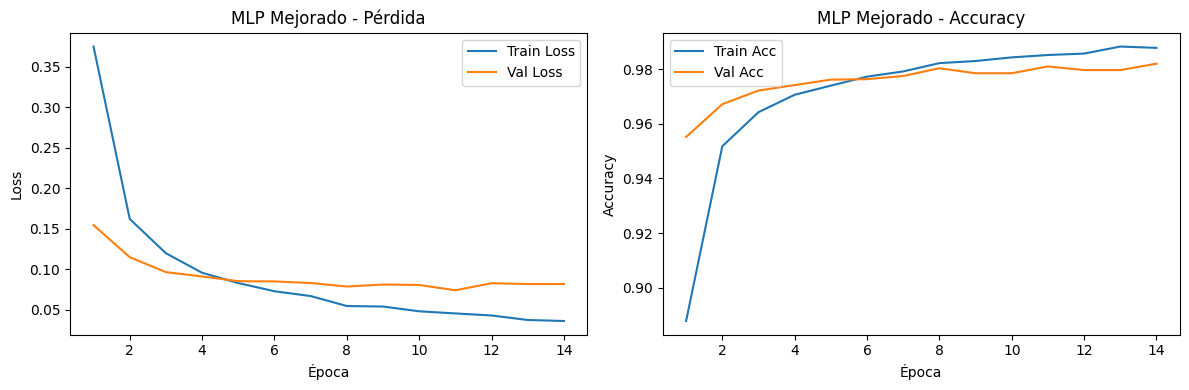

Comparación (ANTES vs DESPUÉS)
Accuracy base     : 0.9733
Accuracy mejorado : 0.9807
Diferencia Acc    : +0.0074
Loss base         : 0.1040
Loss mejorado     : 0.0680
Diferencia Loss   : -0.0360


In [66]:
plot_history(history_improved, title_prefix='MLP Mejorado')

test_loss_imp, test_acc_imp = improved_model.evaluate(X_test_flat, y_test, verbose=0)

print('Comparación (ANTES vs DESPUÉS)')
print(f'Accuracy base     : {test_acc_base:.4f}')
print(f'Accuracy mejorado : {test_acc_imp:.4f}')
print(f'Diferencia Acc    : {test_acc_imp - test_acc_base:+.4f}')
print(f'Loss base         : {test_loss_base:.4f}')
print(f'Loss mejorado     : {test_loss_imp:.4f}')
print(f'Diferencia Loss   : {test_loss_imp - test_loss_base:+.4f}')

In [67]:
# Análisis de mejora del modelo (obligatorio)
delta_acc = test_acc_imp - test_acc_base
delta_loss = test_loss_imp - test_loss_base

if delta_acc > 0:
    verdict = 'Sí, mejoró respecto a la línea base.'
else:
    verdict = 'No mejoró; se requiere ajustar hiperparámetros o arquitectura.'

display(Markdown(f"""
### 🚀 Análisis de mejora (antes vs después)
- **¿Qué cambié?** Aumenté capacidad (256-128), agregué **Dropout** y usé **EarlyStopping**.
- **¿Por qué debería mejorar?** Dropout reduce sobreajuste y EarlyStopping evita entrenar más allá del punto de mejor validación.
- **¿Mejoró realmente?** **{verdict}**
- **Comparación cuantitativa:** Δaccuracy = **{delta_acc:+.4f}**, Δloss = **{delta_loss:+.4f}** (mejor si Δloss < 0).
"""))



### 🚀 Análisis de mejora (antes vs después)
- **¿Qué cambié?** Aumenté capacidad (256-128), agregué **Dropout** y usé **EarlyStopping**.
- **¿Por qué debería mejorar?** Dropout reduce sobreajuste y EarlyStopping evita entrenar más allá del punto de mejor validación.
- **¿Mejoró realmente?** **Sí, mejoró respecto a la línea base.**
- **Comparación cuantitativa:** Δaccuracy = **+0.0074**, Δloss = **-0.0360** (mejor si Δloss < 0).


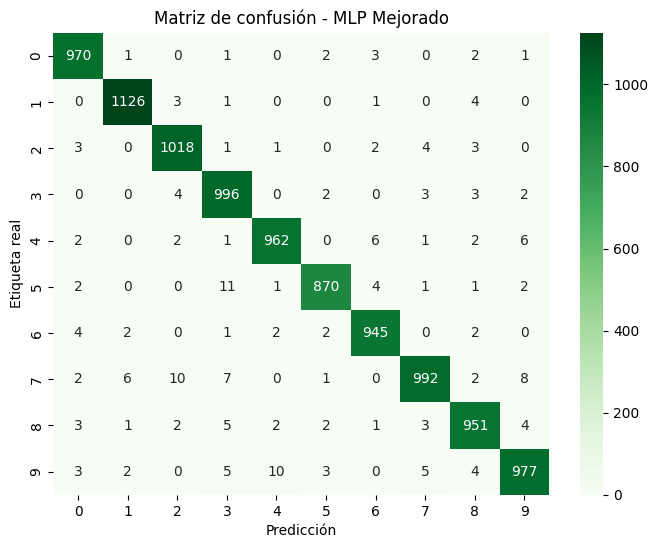

In [64]:
# Matriz de confusión modelo mejorado
y_proba_imp = improved_model.predict(X_test_flat, verbose=0)
y_pred_imp = np.argmax(y_proba_imp, axis=1)

cm_imp = confusion_matrix(y_test, y_pred_imp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - MLP Mejorado')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.show()

## 11) Conclusiones

1. **Aprendizaje logrado:** el paso de perceptrón simple a MLP permite modelar relaciones no lineales, haciendo viable la clasificación multiclase en imágenes.
2. **Limitaciones del MLP:** al aplanar la imagen, el modelo ignora la estructura espacial local (vecindad de píxeles), lo que afecta casos ambiguos.
3. **Por qué una CNN sería mejor:** las CNN explotan patrones espaciales mediante convoluciones y *pooling*, por eso suelen superar a un MLP en visión por computador.
4. **Relación con la clase:** esta implementación aterriza conceptos centrales de la Clase 1: perceptrón, activaciones, backpropagation, aprendizaje supervisado y necesidad de arquitecturas más expresivas.

---
### Checklist de entrega
- [x] Marco teórico conectado con implementación.
- [x] EDA y preprocesamiento claros.
- [x] Modelo base + modelo mejorado.
- [x] Curvas de entrenamiento y análisis.
- [x] Matriz de confusión + ejemplos mal clasificados.
- [x] Conclusiones alineadas a teoría de la clase.